# IEOR 4578 — Homework 3
## Time Series: Convolution, MA, AR Processes, Butterworth Filter & Circadian Rhythm

## Setup

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import adfuller

os.makedirs('images', exist_ok=True)

## Load Datasets
| Dataset | Frequency | Column | Records |
|---|---|---|---|
| Viscosity | Hourly | `Viscosity Hourly` | 100 |
| WholeFood | Weekly | `Weekly Sales` | 248 |
| Pharmaceutical | Weekly | `Weekly_Sales` | 120 |
| Ice Cream (FRED) | Monthly | `IPN31152N` | 602 |
| HRV Wearable | ~5 min | `HR` | 79 639 (49 subjects) |

In [2]:
dv    = pd.read_excel('datasets/Viscosity.xlsx')
dw    = pd.read_excel('datasets/WholeFood.xlsx')
dp    = pd.read_excel('datasets/Pharmaceutical.xlsx')
dicfn = pd.read_csv(
    'datasets/IPN31152N_Fred_Industrial Production Manufacturing '
    'Non-Durable Goods Ice Cream and Frozen Dessert.csv'
)
dicfn.DATE = pd.to_datetime(dicfn.DATE)

dhr = pd.read_csv('datasets/sensor_hrv.csv')
ds  = dhr[['deviceId', 'ts_start', 'ts_end', 'HR']].copy()
ds['ts_utc'] = pd.to_datetime(ds['ts_start'], unit='ms', utc=True)
ds = ds.sort_values(by=['deviceId', 'ts_start'])

display(dv.head(3))
display(dw.head(3))
display(dp.head(3))
display(dicfn.head(3))
display(ds.head(3))

,Viscosity Hourly
0,86.7418
1,85.3195
2,84.7355


,Weekly Sales
0,28.05
1,28.23
2,26.25


,Weekly_Sales
0,10618.1
1,10537.9
2,10209.3


,DATE,IPN31152N
0,1972-01-01,60.1527
1,1972-02-01,67.2736
2,1972-03-01,74.4710


,deviceId,ts_start,ts_end,HR,ts_utc
1814,ab60,1614830408336,1614830695933,105.805861,2021-03-04 04:00:08.336000+00:00
1813,ab60,1614831011192,1614831311031,95.268571,2021-03-04 04:10:11.192000+00:00
1841,ab60,1614831311233,1614831611038,98.833390,2021-03-04 04:15:11.233000+00:00


---
## Question 1 — Convolution and Moving Average

### What these two methods do

**Convolution** replaces each point with a weighted sum of its neighbours. Using a flat (rectangular) kernel of width *w*, every output point is the arithmetic mean of *w* values centred on that location — computed via FFT-based polynomial multiplication.

**Moving Average (MA)** slides a window forward one step at a time. With `center=True` the window is centred, making it directly comparable to convolution.

**Edge handling — why reflect-padding matters:**  
The naive `mode='same'` pads the signal with **zeros** at both ends. For a window of width *w* this contaminates the first and last *w/2* output values — the filter 'sees' zeros that don't exist, pulling the smoothed curve toward zero at the edges. **Reflect-padding** mirrors the signal at each boundary before convolving, then trims back to the original length — no artificial zero-pull, no extra parameters:

```python
padded   = np.pad(s1, (w//2, (w-1)//2), mode='reflect')
filtered = signal.convolve(padded, weights, mode='valid')
```

For w=5 this pads 2 samples on each side; for w=20 it pads 10/9 samples.  
The output length is always exactly *n* — no time-axis shift needed.

We apply w ∈ {5, 10, 20} to all four datasets. Top panel = convolution, bottom panel = centered MA.

In [3]:
def plot_q1(s1, title, fname):
    """One figure per dataset: 3 rows (w=5/10/20), conv + MA overlaid on the same axis."""
    t = np.arange(len(s1))

    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    fig.suptitle(f'{title} — Convolution & Moving Average', fontsize=13, fontweight='bold')

    for ax, w in zip(axes, [5, 10, 20]):
        weights  = [1/w] * w

        # Reflect-padded convolution — no zero-edge artifact
        padded   = np.pad(s1, (w//2, (w-1)//2), mode='reflect')
        conv     = signal.convolve(padded, weights, mode='valid')

        # Centered MA — same alignment as convolution
        ma = pd.Series(s1).rolling(w, center=True).mean().values

        ax.plot(t, s1,   color='black',     linewidth=0.8, alpha=0.45, label='Data')
        ax.plot(t, conv, color='steelblue', linewidth=2,   linestyle='--', label=f'Convolution (w={w})')
        ax.plot(t, ma,   color='firebrick', linewidth=2,   linestyle=':',  label=f'MA (w={w})')
        ax.set_ylabel('X(t)', fontsize=11)
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, linewidth=0.5, alpha=0.5)
        ax.set_xlim(0, len(s1))

    axes[-1].set_xlabel('t', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'images/{fname}.png', dpi=130)
    plt.show()

### Q1 · Viscosity (Hourly)

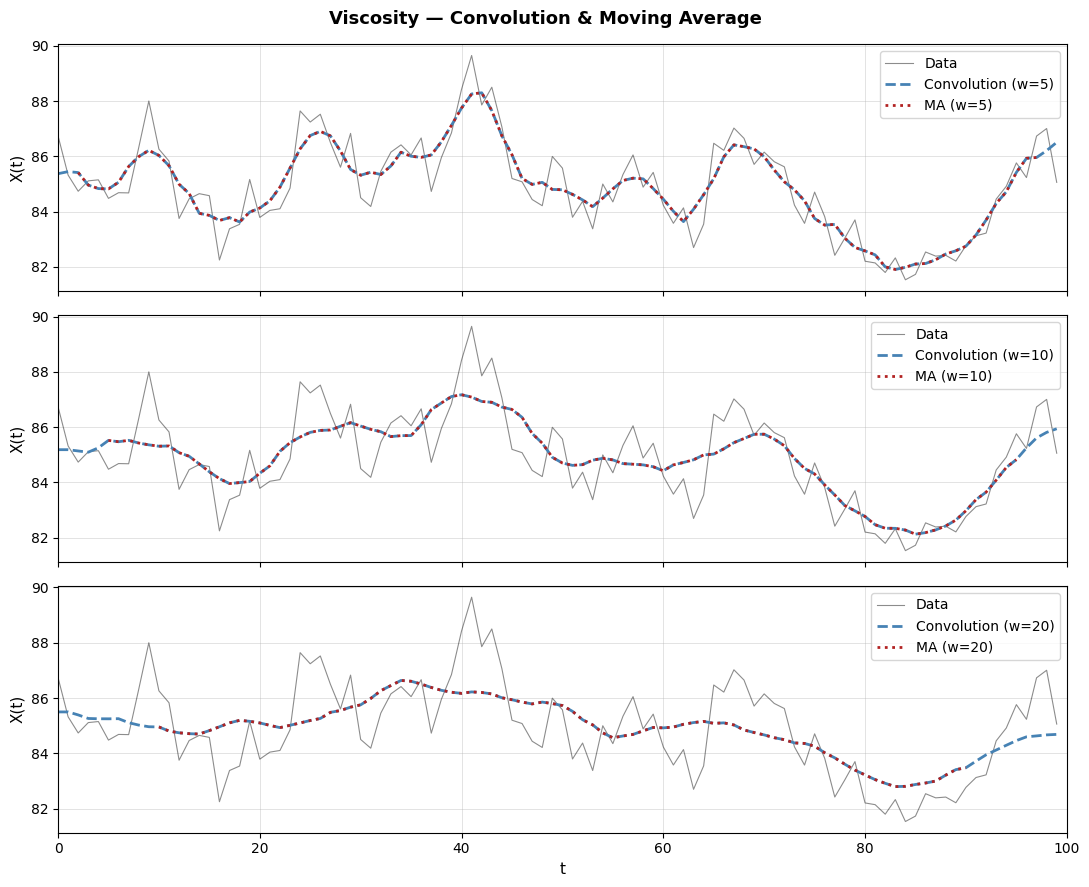

In [4]:
plot_q1(dv['Viscosity Hourly'].values, 'Viscosity', 'Viscosity_MA_Conv')

### Q1 · WholeFood (Weekly)

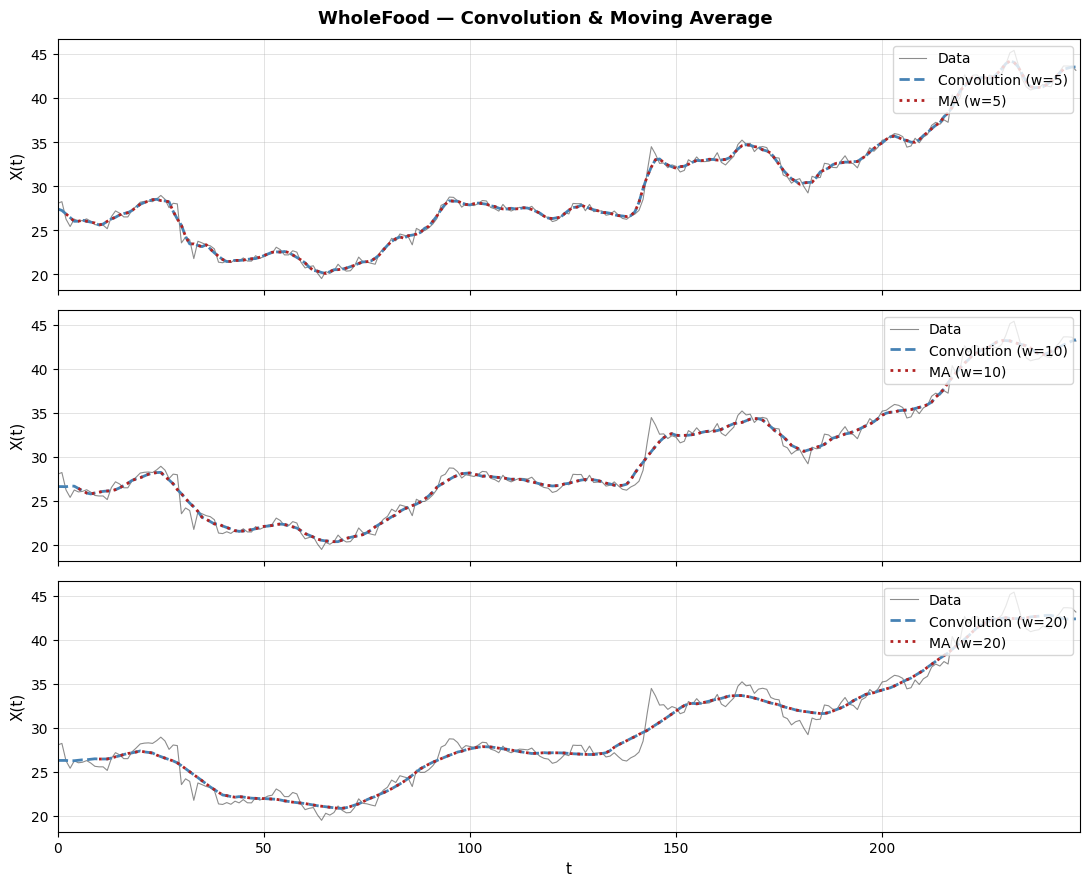

In [5]:
plot_q1(dw['Weekly Sales'].values, 'WholeFood', 'WholeFood_MA_Conv')

### Q1 · Pharmaceutical (Weekly)

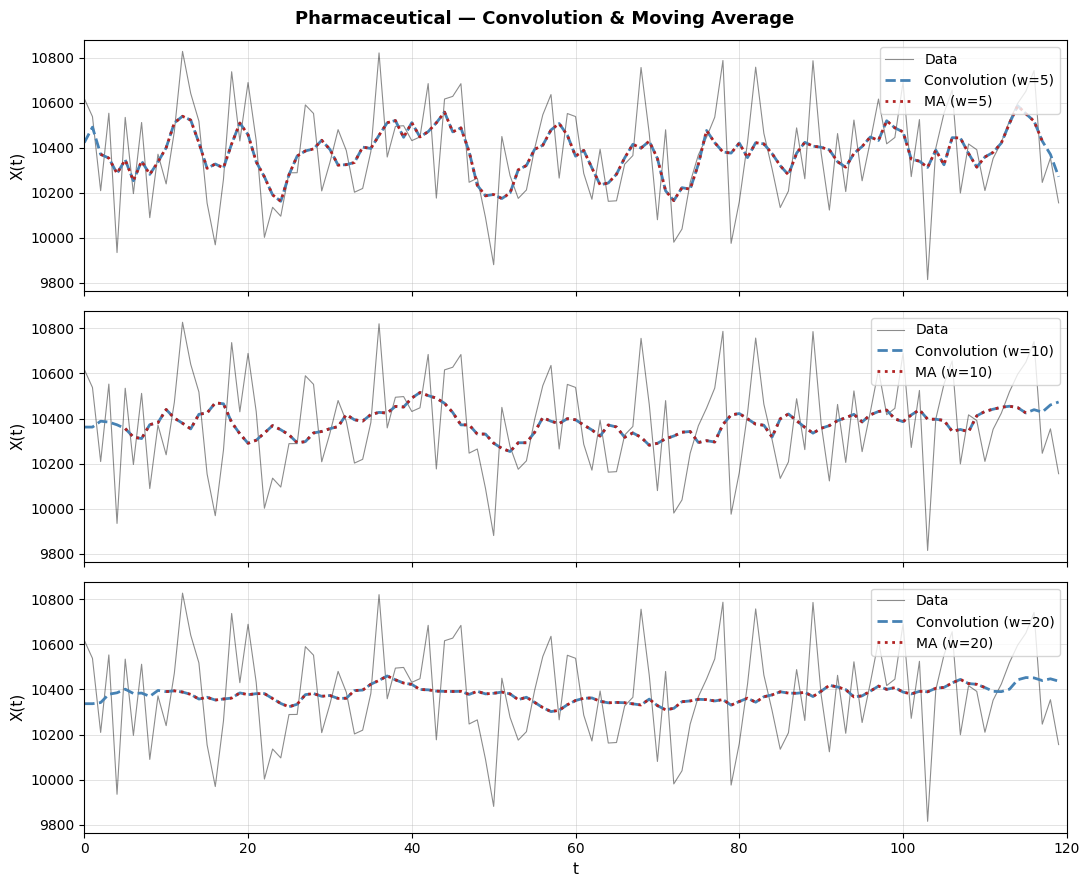

In [6]:
plot_q1(dp['Weekly_Sales'].values, 'Pharmaceutical', 'Pharmaceutical_MA_Conv')

### Q1 · Ice Cream — FRED (Monthly)

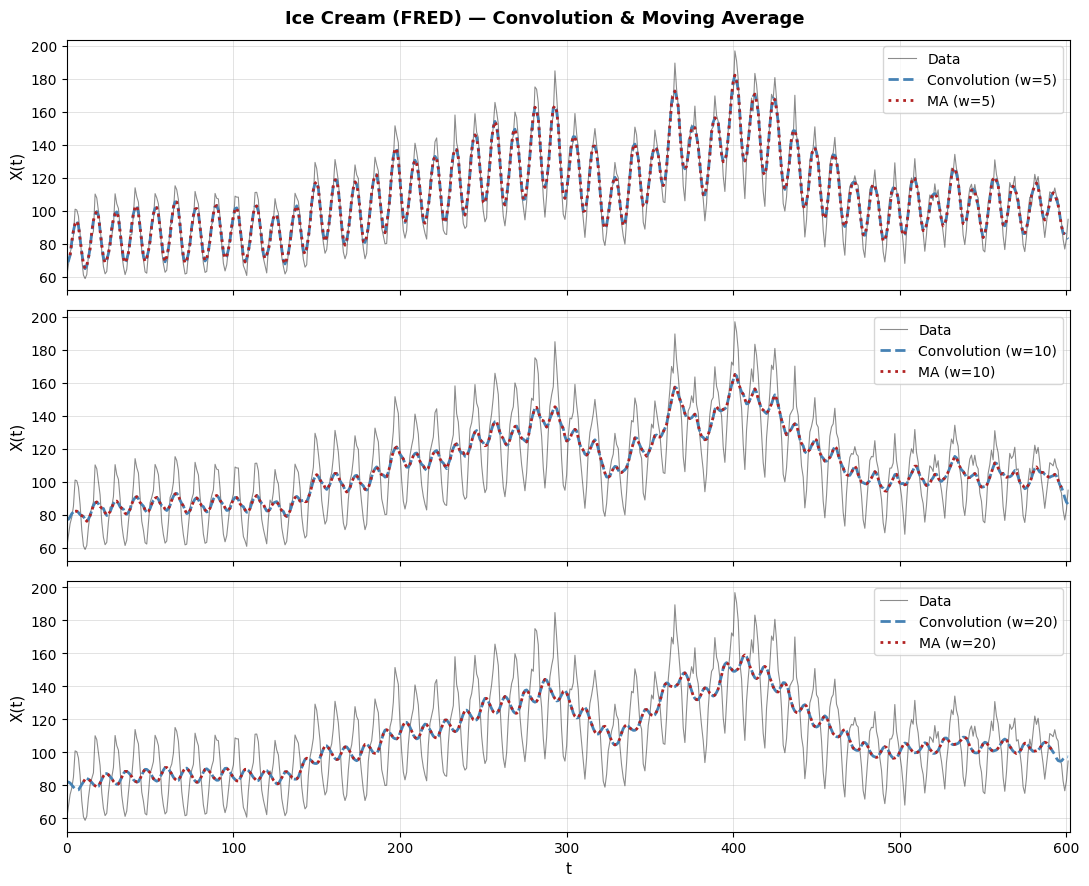

In [7]:
plot_q1(dicfn['IPN31152N'].values, 'Ice Cream (FRED)', 'IceCream_MA_Conv')

---
## Question 2 — AR Processes

### What is an Autoregressive (AR) process?

An **AR(p)** model says the current value depends *linearly* on its own *p* previous values plus a random shock:

$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(\mu, \sigma^2)$$

The parameter **φ** controls *persistence* (memory):
- **φ → 0**: each step is nearly independent — looks like white noise
- **φ → 1**: shocks persist for a long time — series wanders slowly
- **|φ| ≥ 1** (or **φ₁+φ₂ ≥ 1** for AR(2)): process is *non-stationary* — variance grows without bound (explosive)

**Stationarity conditions for AR(2):** φ₁+φ₂ < 1 · φ₂−φ₁ < 1 · |φ₂| < 1. The pair (0.9, 0.9) violates the first → explosive series.

### Q2 · AR(1): c=0, φ ∈ {0.01, 0.5, 0.9}

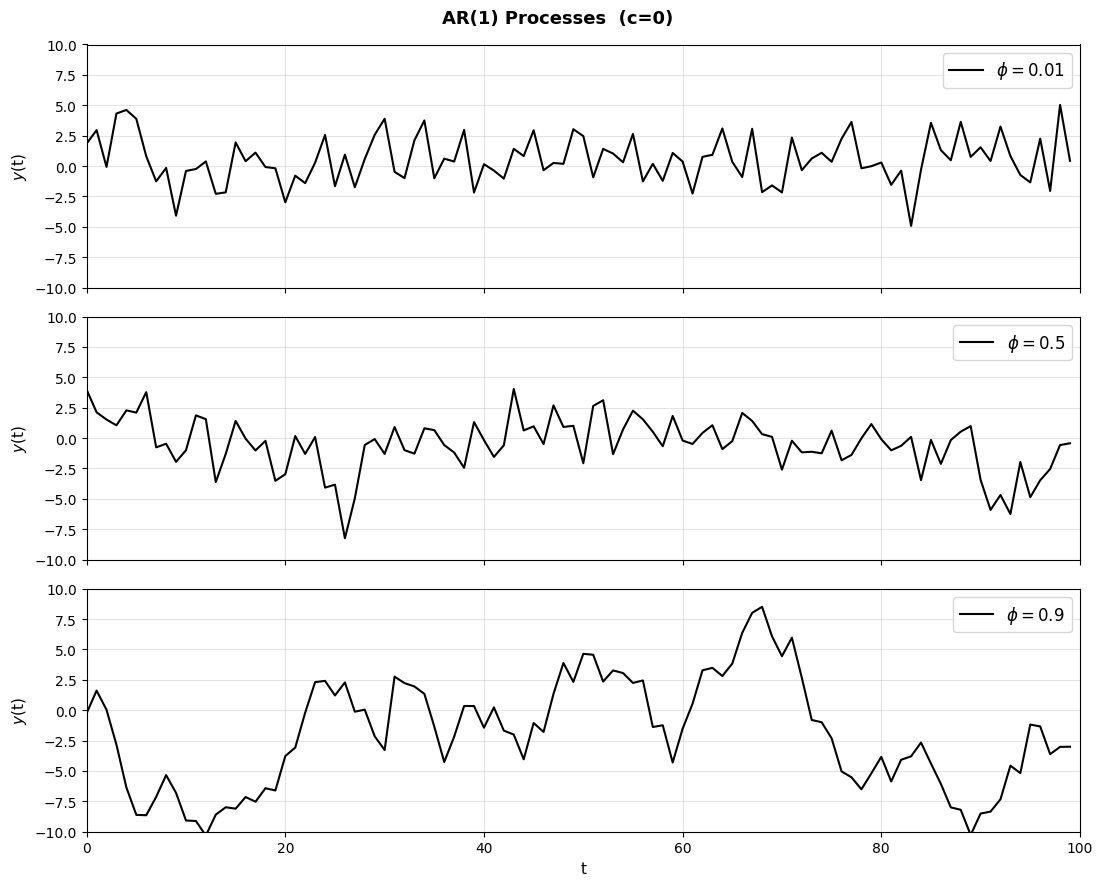

In [8]:
def myAutoReg(y, n, c, phi, mu, sigma):
    return c + np.random.normal(mu, sigma) + phi * y

mu, sigma, c = 0, 2, 0
t = np.arange(100)

configs = [(0.01, '$\\phi=0.01$'), (0.5, '$\\phi=0.5$'), (0.9, '$\\phi=0.9$')]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle('AR(1) Processes  (c=0)', fontsize=13, fontweight='bold')

for ax, (phi, label) in zip(axes, configs):
    y = np.zeros(100)
    y[0] = np.random.normal(mu, sigma)
    for i in np.arange(99) + 1:
        y[i] = myAutoReg(y[i-1], i, c, phi, mu, sigma)
    ax.plot(t, y, 'k', linewidth=1.5)
    ax.set_xlim(0, 100)
    ax.set_ylim(-10, 10)
    ax.set_ylabel('$y$(t)', fontsize=11)
    ax.legend([label], fontsize=12, loc='upper right')
    ax.grid(True, linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('t', fontsize=11)
plt.tight_layout()
plt.savefig('images/AR_1_c0.png', dpi=130)
plt.show()

### Q2 · AR(2): c=0, (φ₁, φ₂) combinations

AR(2) has **two lag terms**, letting the model capture oscillatory or more complex autocorrelation patterns that AR(1) cannot. Notice how (0.9, 0.9) diverges — a small initial shock compounds instead of decaying.

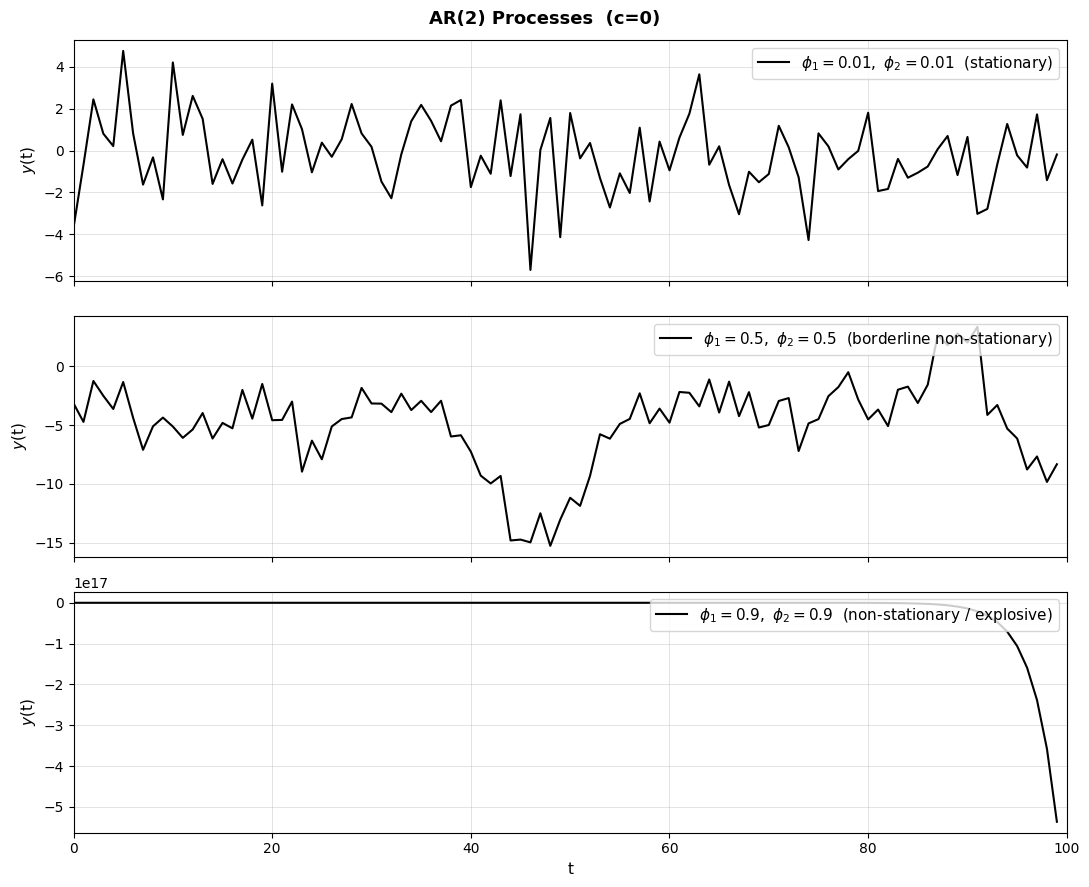

In [9]:
def myAutoReg2(y1, y2, c, phi1, phi2, mu, sigma):
    return c + np.random.normal(mu, sigma) + phi1 * y1 + phi2 * y2

configs2 = [
    (0.01, 0.01, '$\\phi_1=0.01,\\ \\phi_2=0.01$  (stationary)'),
    (0.5,  0.5,  '$\\phi_1=0.5,\\ \\phi_2=0.5$  (borderline non-stationary)'),
    (0.9,  0.9,  '$\\phi_1=0.9,\\ \\phi_2=0.9$  (non-stationary / explosive)'),
]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle('AR(2) Processes  (c=0)', fontsize=13, fontweight='bold')

for ax, (phi1, phi2, label) in zip(axes, configs2):
    y = np.zeros(100)
    y[0] = np.random.normal(mu, sigma)
    y[1] = myAutoReg(y[0], 1, c, phi1, mu, sigma)
    for i in np.arange(98) + 2:
        y[i] = myAutoReg2(y[i-1], y[i-2], c, phi1, phi2, mu, sigma)
    ax.plot(t, y, 'k', linewidth=1.5)
    ax.set_xlim(0, 100)
    ax.set_ylabel('$y$(t)', fontsize=11)
    ax.legend([label], fontsize=11, loc='upper right')
    ax.grid(True, linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('t', fontsize=11)
plt.tight_layout()
plt.savefig('images/AR_2_c0.png', dpi=130)
plt.show()

---
## Question 3 — Butterworth Filter

### What is a Butterworth filter and why use it?

A **Butterworth filter** is an IIR (infinite impulse response) filter with a *maximally flat* passband — no ripple. It attenuates frequencies above the cutoff smoothly and monotonically.

Two modes:
- **Low-Pass (LP):** passes low frequencies (trend), removes high-frequency noise. Useful for detrending.
- **Band-Pass (BP):** passes only a target band (e.g. annual seasonality at 1/12 cycle/month). Useful for isolating seasonal components.

### How the grid search works

The 'right' cutoff is dataset-specific. The code tries every combination of `order` ∈ [3, 19] and sampling frequency `fs` ∈ [order, 29] and picks the pair that **minimises RMSE** between the original signal and the filtered output — lower RMSE means the filter follows the signal closely.

### Five-panel output

| Panel | What it shows |
|---|---|
| 1 | Original signal |
| 2 | PSD of original — peaks reveal dominant frequencies |
| 3 | LP-filtered signal (extracted trend) |
| 4 | Residual = original − filtered (noise removed) |
| 5 | PSD of residual — confirms which frequencies were attenuated |

### When is filtering NOT needed?

The **ADF test** checks for a unit root (non-stationarity). If p < 0.05 the series is already stationary — filtering for stationarity is unnecessary and may harm forecasts by adding lag.

In [10]:
def butterworth_lp(sig, t, label):
    """Grid-search LP Butterworth: minimise RMSE over (order, fs).
    Uses sosfiltfilt (zero-phase, forward-backward) — no startup transient."""
    RMSE  = 10000000000
    fss   = 0
    order = 0

    for i in np.arange(3, 20):
        for j in np.arange(i, 30):
            sos      = signal.butter(i, 1, 'lowpass', fs=j, output='sos')
            filtered = signal.sosfiltfilt(sos, sig)   # zero-phase: no transient spike
            MSE      = np.square(sig - filtered).mean()
            if RMSE > math.sqrt(MSE):
                RMSE  = math.sqrt(MSE)
                order = i
                fss   = j

    sos      = signal.butter(order, 1, 'lowpass', fs=fss, output='sos')
    filtered = signal.sosfiltfilt(sos, sig)

    freqs_sig, psd_sig = signal.welch(sig)
    freqs_res, psd_res = signal.welch(sig - filtered)

    fig, axes = plt.subplots(5, 1, figsize=(12, 10))
    fig.suptitle(f'{label} — Butterworth LP  (order={order}, fs={fss})',
                 fontsize=13, fontweight='bold')

    axes[0].plot(t, sig, 'k', linewidth=1)
    axes[0].set_ylabel('Signal', fontsize=10)
    axes[0].legend([label], fontsize=10); axes[0].grid(True, linewidth=0.5, alpha=0.5)

    axes[1].plot(freqs_sig, psd_sig, 'k', linewidth=1)
    axes[1].set_ylabel('PSD', fontsize=10)
    axes[1].legend(['PSD of original'], fontsize=10); axes[1].grid(True, linewidth=0.5, alpha=0.5)

    axes[2].plot(t, filtered, 'k', linewidth=1)
    axes[2].set_ylabel('Filtered', fontsize=10)
    axes[2].legend([f'LP filtered'], fontsize=10); axes[2].grid(True, linewidth=0.5, alpha=0.5)

    axes[3].plot(t, sig - filtered, 'k', linewidth=1)
    axes[3].set_ylabel('Residual', fontsize=10)
    axes[3].legend(['Original − LP'], fontsize=10); axes[3].grid(True, linewidth=0.5, alpha=0.5)

    axes[4].plot(freqs_res, psd_res, 'k', linewidth=1)
    axes[4].set_ylabel('PSD residual', fontsize=10)
    axes[4].set_xlabel('freq', fontsize=10)
    axes[4].legend(['PSD of residual'], fontsize=10); axes[4].grid(True, linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'images/{label.replace(" ", "_")}_Butterworth.png', dpi=130)
    plt.show()

    RMSE_final = math.sqrt(np.square(sig - filtered).mean())
    print(f'{label}: order={order}, fs={fss}, RMSE={RMSE_final:.4f}')
    return filtered

### Q3 · Ice Cream — LP (post-2015, matches professor's code)

/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:21: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 74, using nperseg = 74
  freqs_sig, psd_sig = signal.welch(sig)
/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:22: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 74, using nperseg = 74
  freqs_res, psd_res = signal.welch(sig - filtered)


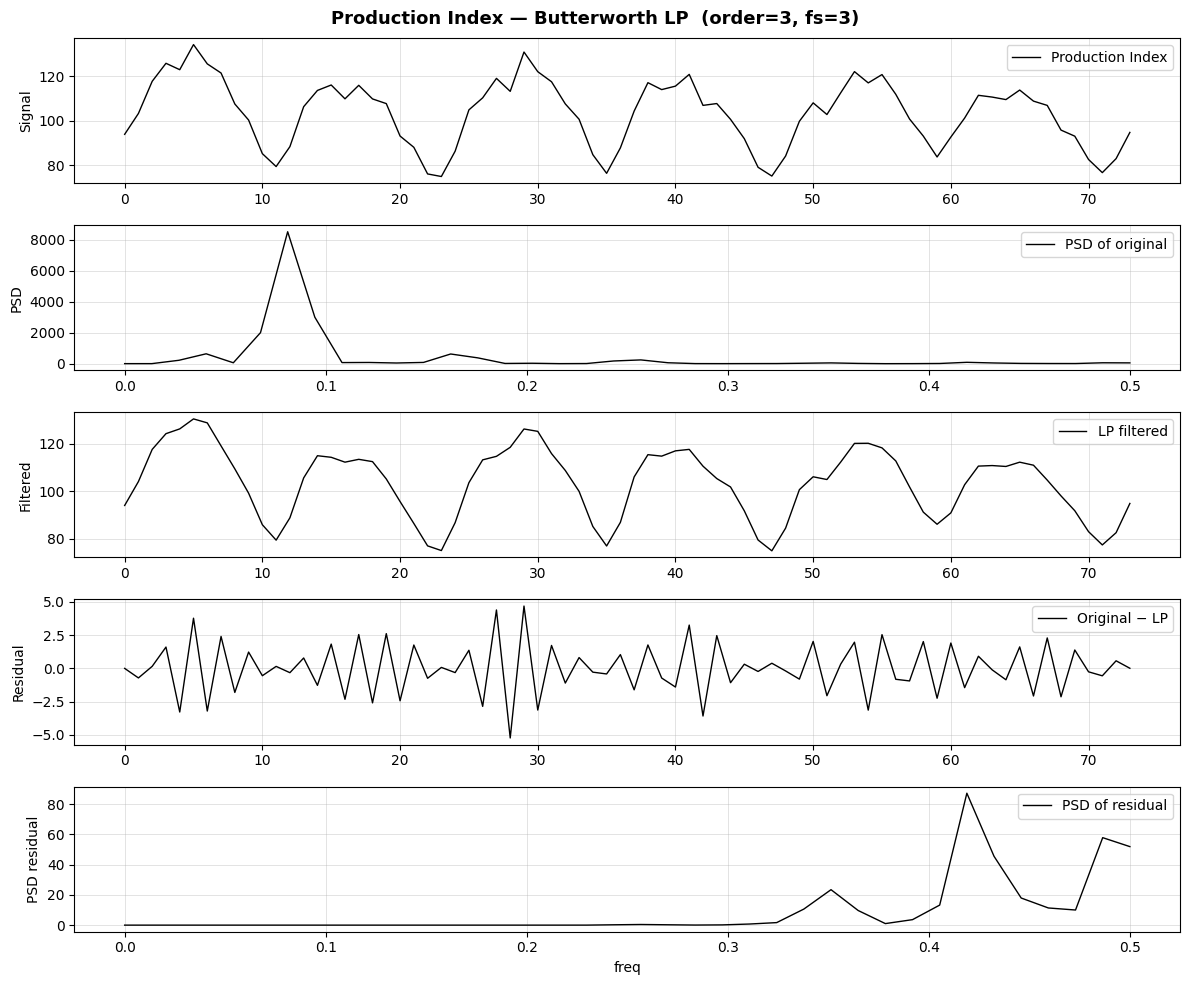

Production Index: order=3, fs=3, RMSE=1.9791


In [11]:
t_ic   = [i % 365 for i in range(0, len(dicfn.DATE[dicfn.DATE.dt.year > 2015]))]
sig_ic = dicfn.IPN31152N[dicfn.DATE.dt.year > 2015].values
filtered_ic = butterworth_lp(sig_ic, t_ic, 'Production Index')

### Q3 · Viscosity — LP

/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:21: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 100, using nperseg = 100
  freqs_sig, psd_sig = signal.welch(sig)
/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:22: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 100, using nperseg = 100
  freqs_res, psd_res = signal.welch(sig - filtered)


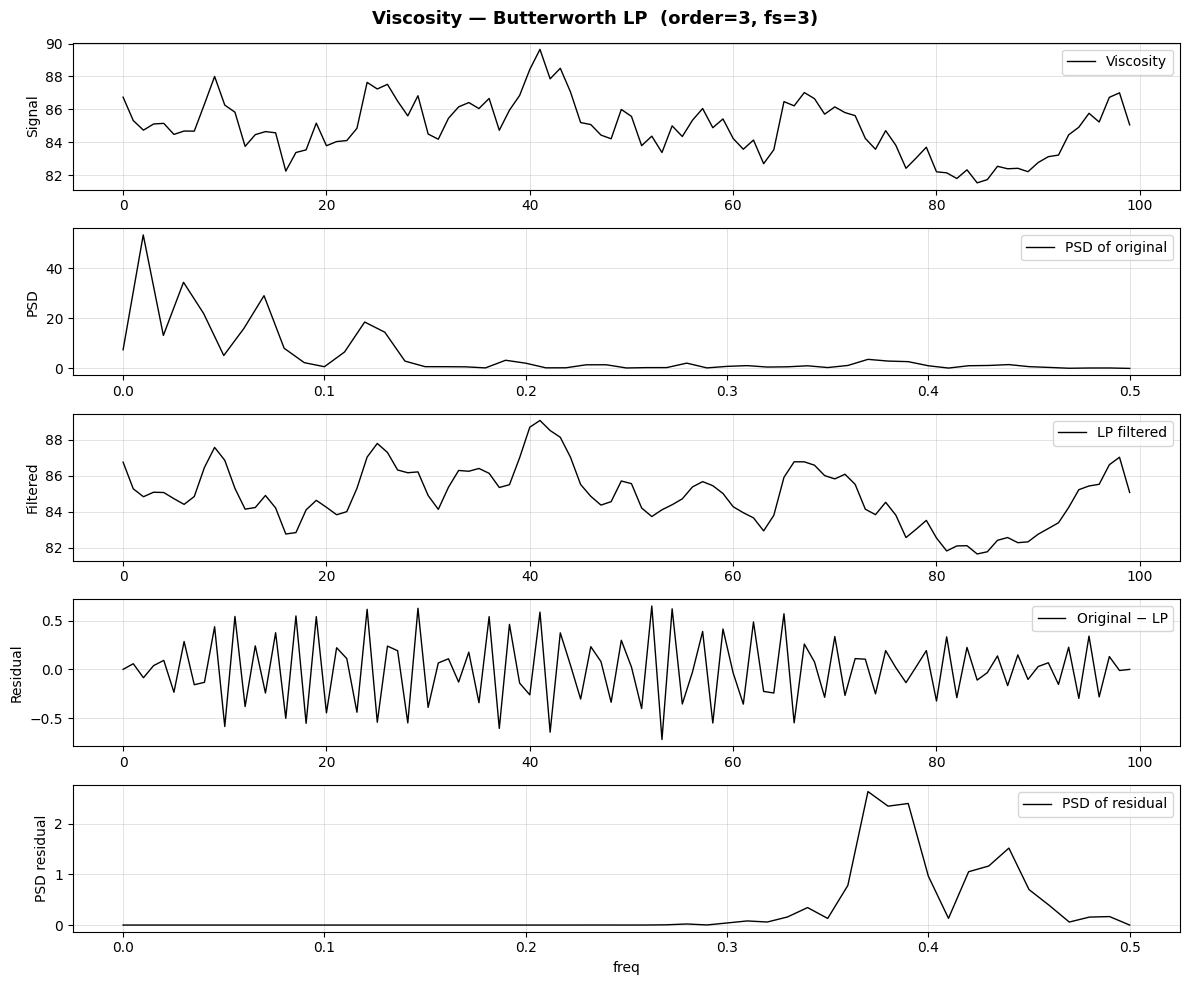

Viscosity: order=3, fs=3, RMSE=0.3429


In [12]:
filtered_v = butterworth_lp(dv['Viscosity Hourly'].values,
                             np.arange(dv.shape[0]), 'Viscosity')

### Q3 · WholeFood — LP

/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:21: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 248, using nperseg = 248
  freqs_sig, psd_sig = signal.welch(sig)
/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:22: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 248, using nperseg = 248
  freqs_res, psd_res = signal.welch(sig - filtered)


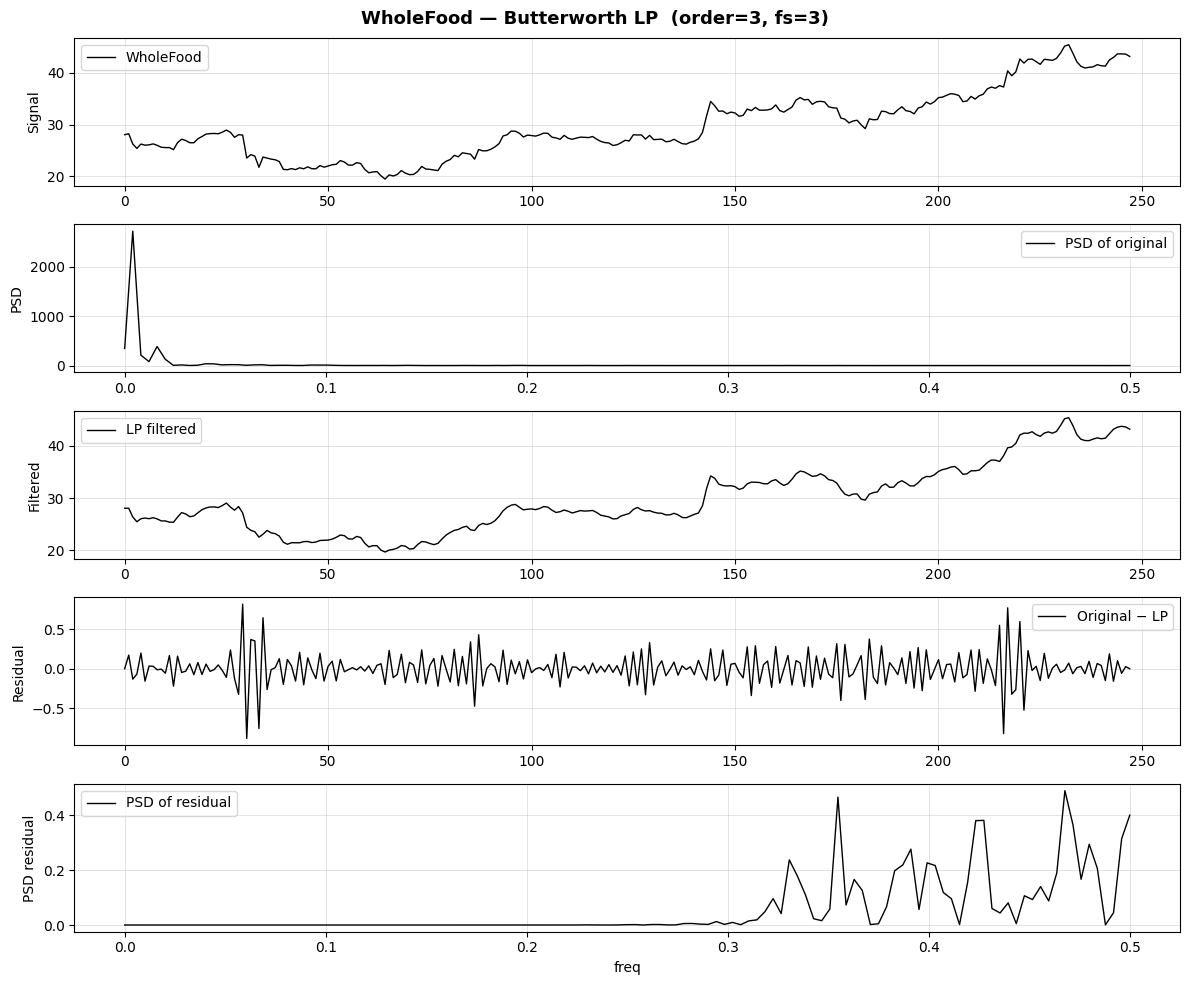

WholeFood: order=3, fs=3, RMSE=0.2107


In [13]:
filtered_w = butterworth_lp(dw['Weekly Sales'].values,
                             np.arange(dw.shape[0]), 'WholeFood')

### Q3 · Pharmaceutical — LP

/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:21: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 120, using nperseg = 120
  freqs_sig, psd_sig = signal.welch(sig)
/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_74625/353278464.py:22: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 120, using nperseg = 120
  freqs_res, psd_res = signal.welch(sig - filtered)


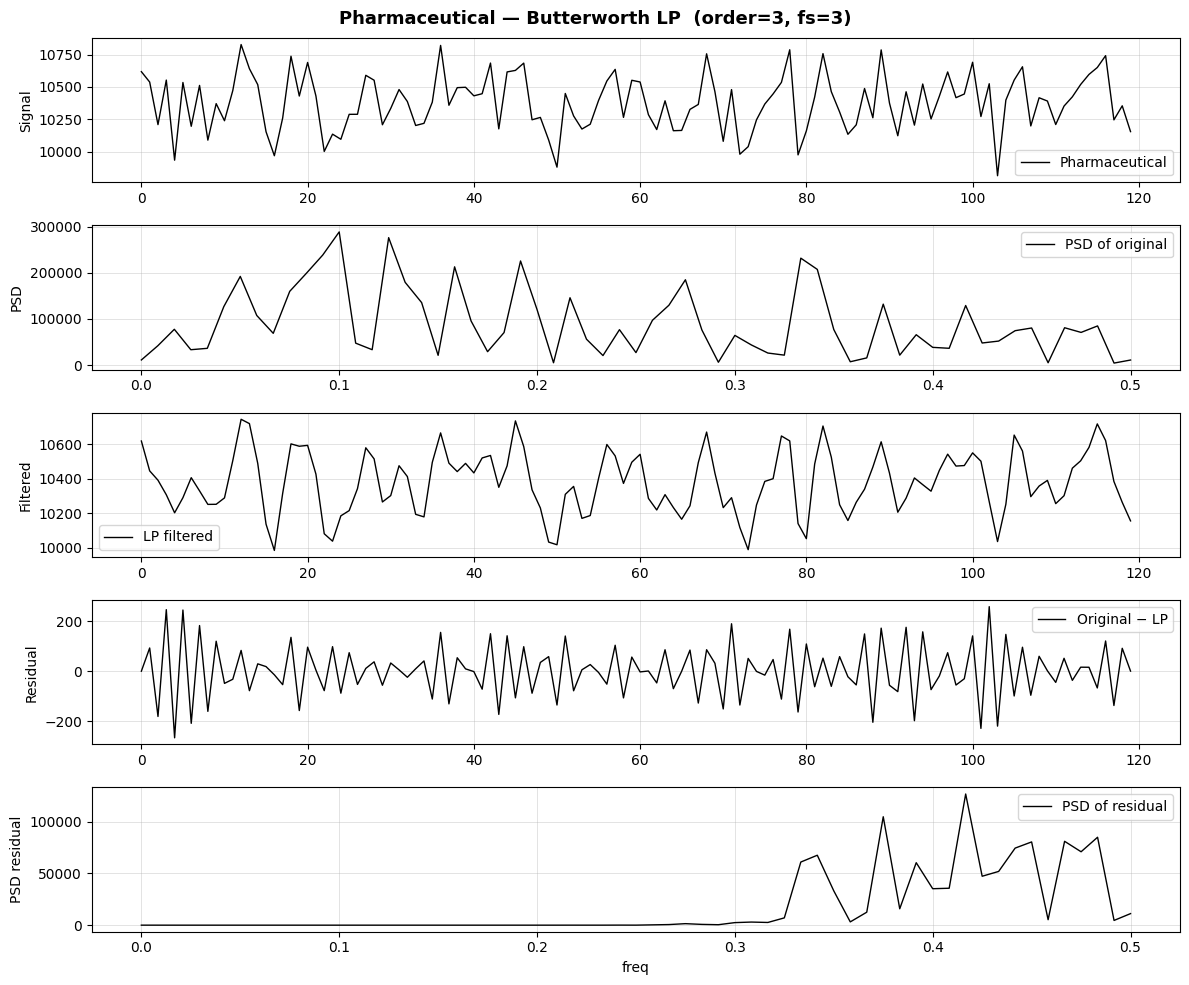

Pharmaceutical: order=3, fs=3, RMSE=109.5517


In [14]:
filtered_p = butterworth_lp(dp['Weekly_Sales'].values,
                             np.arange(dp.shape[0]), 'Pharmaceutical')

### Q3 · Stationarity check — when is filtering not needed?

ADF null hypothesis: unit root present (non-stationary). p < 0.05 → reject null → series is stationary → LP filtering not required for stationarity.

In [15]:
for name, arr in [
    ('Viscosity',             dv['Viscosity Hourly'].values),
    ('WholeFood',             dw['Weekly Sales'].values),
    ('Pharmaceutical',        dp['Weekly_Sales'].values),
    ('Ice Cream (post-2015)', dicfn.IPN31152N[dicfn.DATE.dt.year > 2015].values),
]:
    p       = adfuller(arr)[1]
    verdict = 'Already stationary  →  filtering NOT needed' if p < 0.05               else 'Non-stationary  →  filtering recommended'
    print(f'{name:30s}  ADF p={p:.4f}  |  {verdict}')

Viscosity                       ADF p=0.0085  |  Already stationary  →  filtering NOT needed
WholeFood                       ADF p=0.9691  |  Non-stationary  →  filtering recommended
Pharmaceutical                  ADF p=0.0000  |  Already stationary  →  filtering NOT needed
Ice Cream (post-2015)           ADF p=0.0191  |  Already stationary  →  filtering NOT needed


---
## Question 4 — Circadian Rhythm Modeling

### What is a circadian rhythm in HR data?

The human body follows a roughly 24-hour biological clock. Heart rate reflects this: lower during sleep (parasympathetic dominance) and higher during waking hours (sympathetic activation, physical activity).

### Two approaches

1. **Rolling MA (window=60 samples ≈ 5 hours)** — non-parametric smoothing. Removes short-term noise without assuming any waveform shape.

2. **Cosinor parametric model** — fits the equation from *Modeling the Circadian Rhythm of Heart Rate and Acceleration* (Eq. 1):

$$\text{HR}(t) = \text{MESOR} + A \cdot \cos\!\left(\frac{2\pi(t - \phi)}{24}\right)$$

   | Parameter | Meaning |
   |---|---|
   | MESOR | Mean HR across the day |
   | A (Amplitude) | Half the peak-to-trough swing |
   | φ (Acrophase) | Hour of peak HR |

   Fitted with non-linear least squares (`curve_fit`). Initial guess `p0 = [mean(HR), 10, 12]` assumes peak around noon.

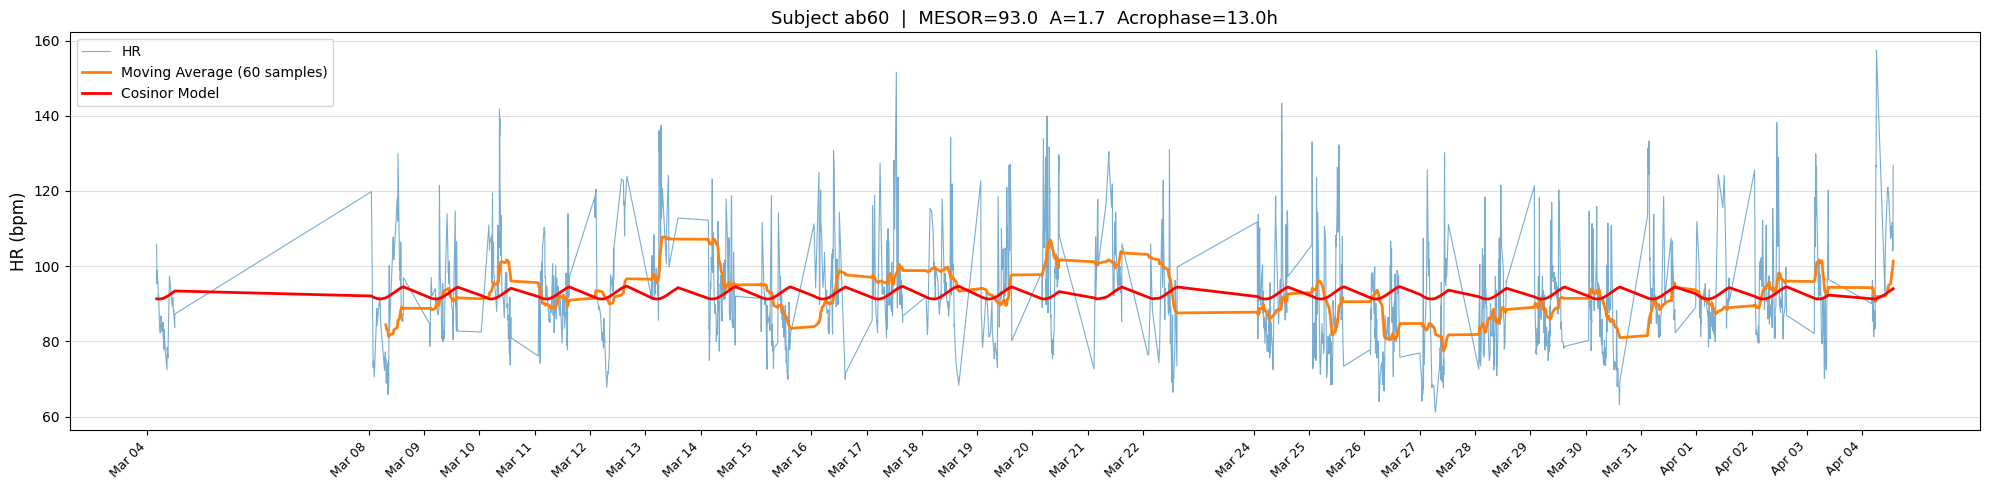

Subject ab60:  MESOR=93.0 bpm  |  Amplitude=1.7 bpm  |  Acrophase=13.0 h


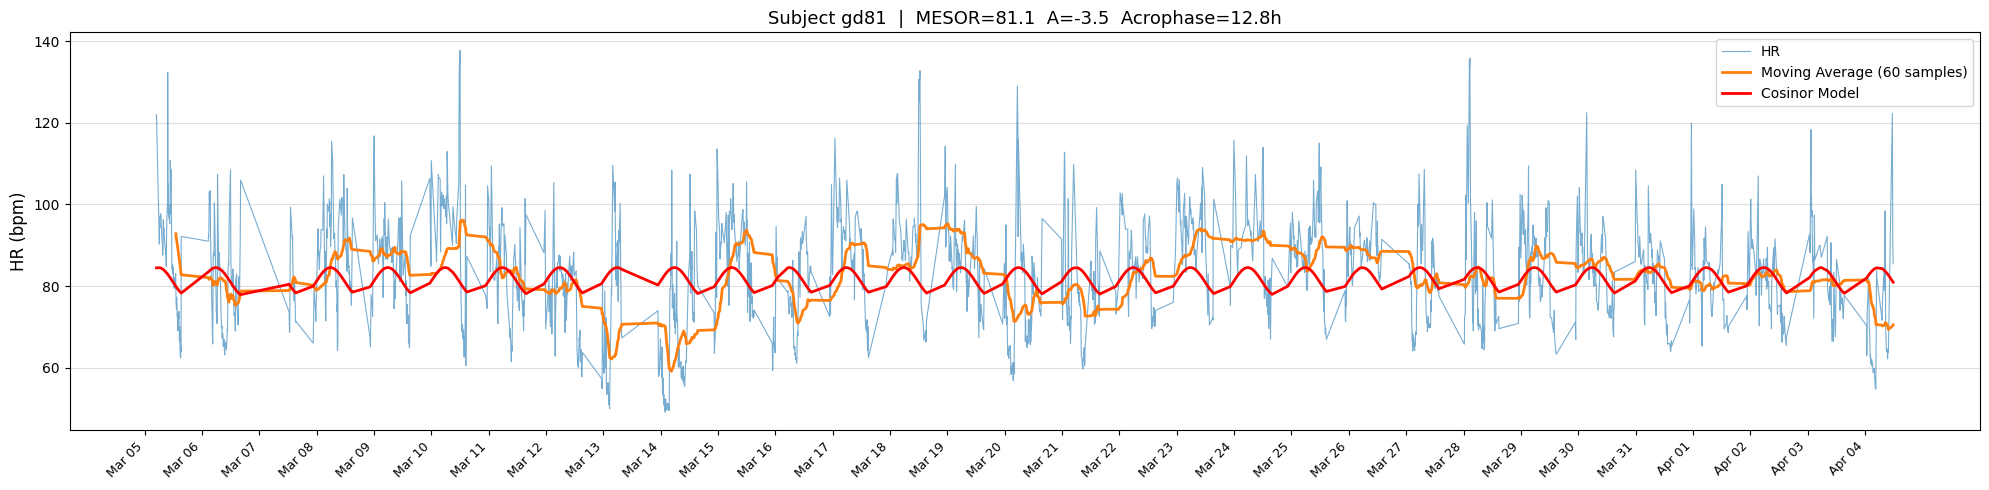

Subject gd81:  MESOR=81.1 bpm  |  Amplitude=-3.5 bpm  |  Acrophase=12.8 h


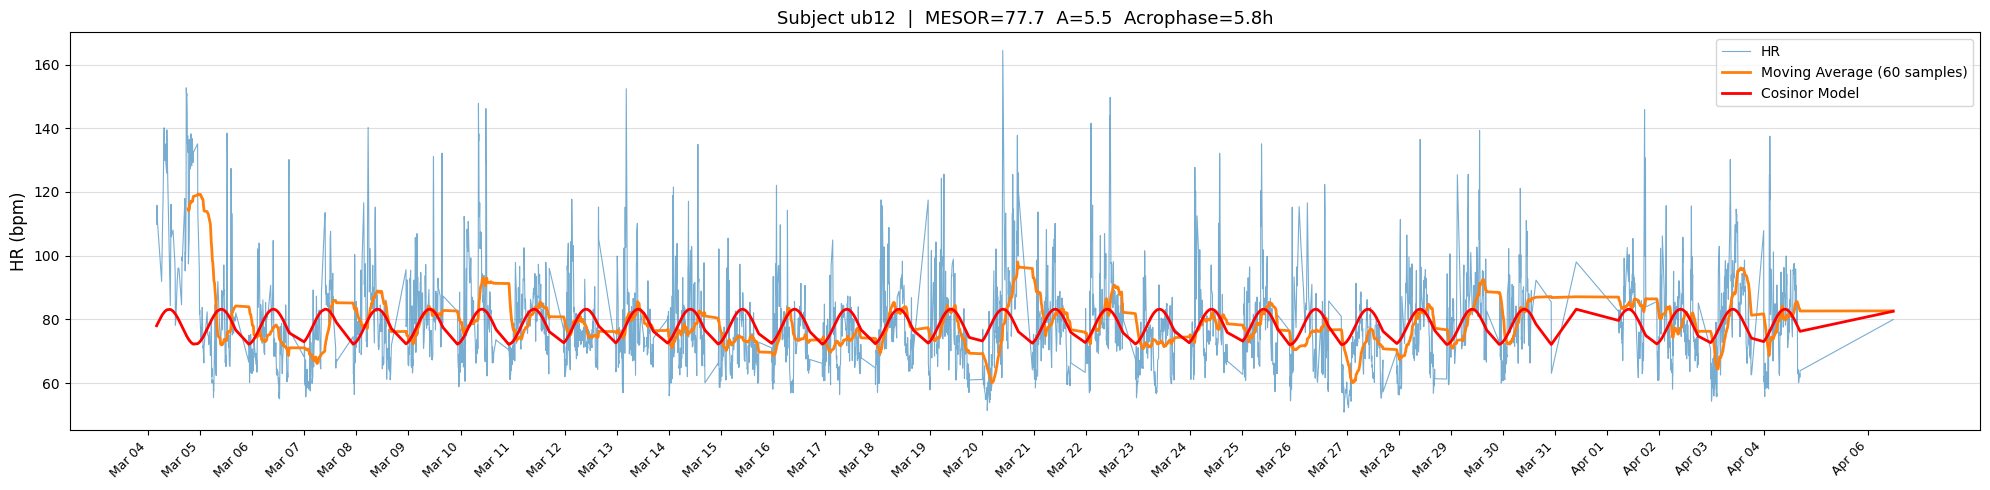

Subject ub12:  MESOR=77.7 bpm  |  Amplitude=5.5 bpm  |  Acrophase=5.8 h


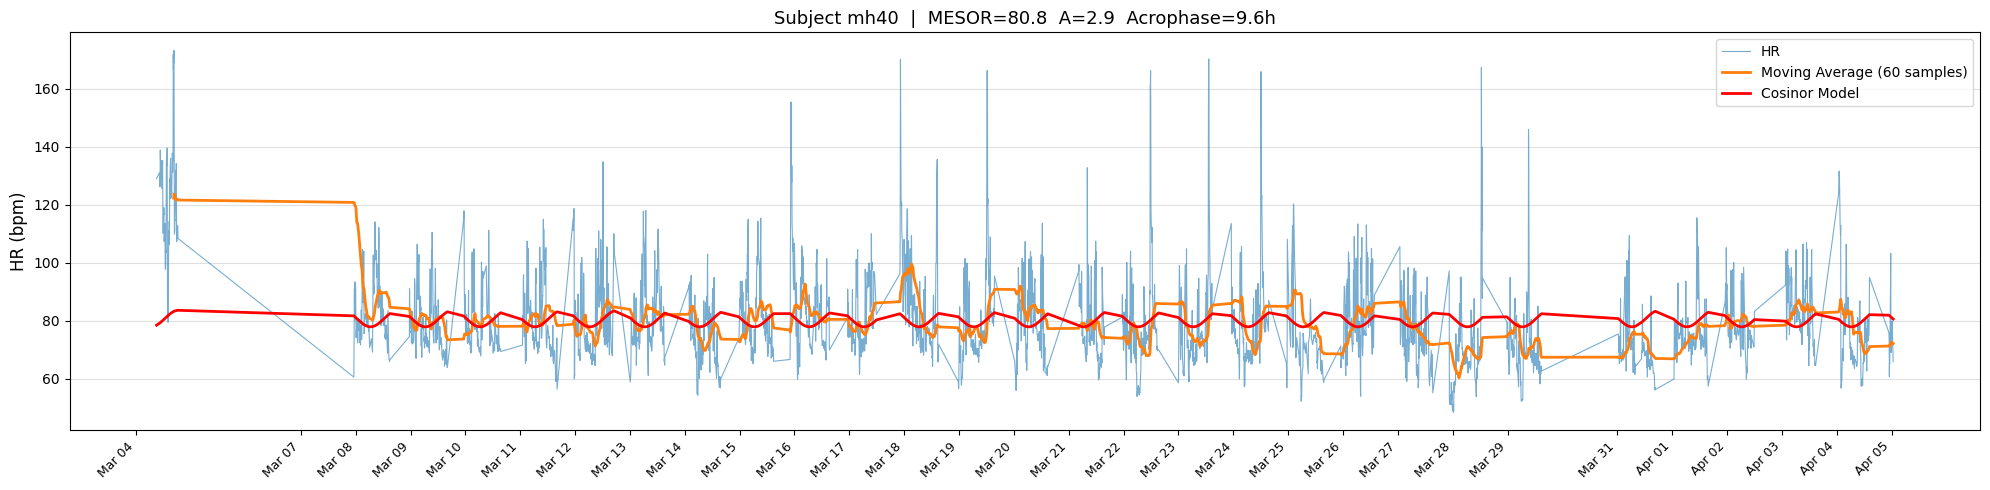

Subject mh40:  MESOR=80.8 bpm  |  Amplitude=2.9 bpm  |  Acrophase=9.6 h


In [16]:
def cosinor_model(t, mesor, amplitude, phase):
    return mesor + amplitude * np.cos(2 * np.pi * (t - phase) / 24)

for x in ['ab60', 'gd81', 'ub12', 'mh40']:

    subset = ds[ds.deviceId == x].copy()
    subset['hour_index'] = (
        subset['ts_utc'] - subset['ts_utc'].min()
    ).dt.total_seconds() / 3600

    # Fit cosinor model
    params, _ = curve_fit(
        cosinor_model, subset['hour_index'], subset['HR'],
        p0=[subset['HR'].mean(), 10, 12]
    )
    subset['circadian_cosinor'] = cosinor_model(subset['hour_index'], *params)

    fig = plt.figure(figsize=(20, 5))

    plt.plot(subset['ts_utc'], subset['HR'], linewidth=0.8, alpha=0.6)
    plt.plot(subset['ts_utc'], subset['HR'].rolling(window=60).mean(), linewidth=2)
    plt.plot(subset['ts_utc'], subset['circadian_cosinor'], linewidth=2, color='r')

    plt.ylabel('HR (bpm)', fontsize=12)
    plt.title(f'Subject {x}  |  MESOR={params[0]:.1f}  A={params[1]:.1f}  '
              f'Acrophase={params[2]:.1f}h', fontsize=13)

    # Daily ticks — one per day, readable
    daily_ticks = subset['ts_utc'].dt.floor('D').drop_duplicates().values
    daily_labels = [pd.Timestamp(d).strftime('%b %d') for d in daily_ticks]
    plt.xticks(ticks=daily_ticks, labels=daily_labels, fontsize=9, rotation=45, ha='right')

    plt.legend(['HR', 'Moving Average (60 samples)', 'Cosinor Model'], fontsize=10)
    plt.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'images/Circadian_Rhythm_{x}.png', dpi=120)
    plt.show()

    print(f'Subject {x}:  MESOR={params[0]:.1f} bpm  |  '
          f'Amplitude={params[1]:.1f} bpm  |  Acrophase={params[2]:.1f} h')